In [1]:
import numpy as np
from compartments import CompartmentPatchArray, SEIRV_patch_stepper

In [ ]:
NUMPATCHES = 2
NUMCOMPARTMENTS = 5

# Patches not communicating with each other

Patch has a 0 contact rate while the other has a finite contact rate, then we expect one patch to have no growth in infection. To remove all sources of randomness we plug the 

In [ ]:
init_state = np.array([[10000, 3, 2, 0, 0], [10000, 3, 2, 0, 0]], dtype = float)
seirv_state = CompartmentPatchArray(
    state= init_state,
    num_compartments=NUMCOMPARTMENTS,
    num_patches=NUMPATCHES,
    iter_num=0
)


In [15]:
vaccinations = np.array((0,0))
VACCINE_EFFICACY = 0
WEIBULL_WANING_SHAPE = 0
WEIBULL_WANING_SCALE = 0
params_stepper = {
        'gamma': 1/5,
        'alpha': 1/5.8,
        'vaccination_14_days_prior': vaccinations,
        'vaccine_efficacy': VACCINE_EFFICACY,
        'waning_weibull_shape': WEIBULL_WANING_SHAPE,
        'waning_weibull_scale': WEIBULL_WANING_SCALE
        }

In [16]:
patchstates = []
STEPS = 100
betas_patches = np.array((0, 1))
network_matrix = np.eye(2)
for i in range(STEPS):
    step = SEIRV_patch_stepper(
        compartment_patch_array=seirv_state,
        network_matrix=network_matrix,
        betas_patches=betas_patches,
        **params_stepper
    )
    patchstates.append(seirv_state.get_copy_of_the_state())
    seirv_state.update_state(seirv_state.state + step)
    seirv_state.incr_iter_num()


In [17]:
patchstates = np.array(patchstates)
patchstates.shape

(100, 2, 5)

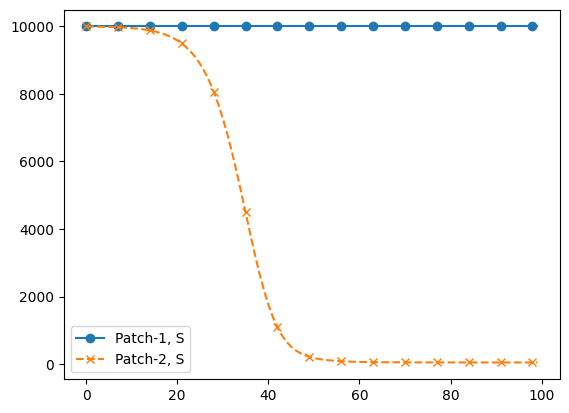

In [18]:
import matplotlib.pyplot as plt

plt.plot(patchstates[:,0, 0], marker = 'o', markevery = 7, label = 'Patch-1, S')
plt.plot(patchstates[:,1, 0], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, S')
plt.legend()

# Patches communicating only with each other

In [42]:
init_state = np.array([[10000, 3, 2, 0, 0], [10000, 3, 2, 0, 0]], dtype = float)
seirv_state = CompartmentPatchArray(
    state= init_state,
    num_compartments=NUMCOMPARTMENTS,
    num_patches=NUMPATCHES,
    iter_num=0
)


In [43]:
vaccinations = np.array((0,0))
VACCINE_EFFICACY = 1
WEIBULL_WANING_SHAPE = 5.7
WEIBULL_WANING_SCALE = 120
params_stepper = {
        'gamma': 1/5,
        'alpha': 1/5.8,
        'vaccination_14_days_prior': vaccinations,
        'vaccine_efficacy': VACCINE_EFFICACY,
        'waning_weibull_shape': WEIBULL_WANING_SHAPE,
        'waning_weibull_scale': WEIBULL_WANING_SCALE
        }

In [44]:
patchstates = []
STEPS = 200
betas_patches = np.array((1, 1))
network_matrix = np.array(((0, 1), (1, 0)))
for i in range(STEPS):
    step = SEIRV_patch_stepper(
        compartment_patch_array=seirv_state,
        network_matrix=network_matrix,
        betas_patches=betas_patches,
        **params_stepper
    )
    # print('-------\n', seirv_state.state, '\n ')
    # print(step)
    patchstates.append(seirv_state.get_copy_of_the_state())
    seirv_state.update_state(seirv_state.state + step)
    seirv_state.incr_iter_num()
patchstates = np.array(patchstates)

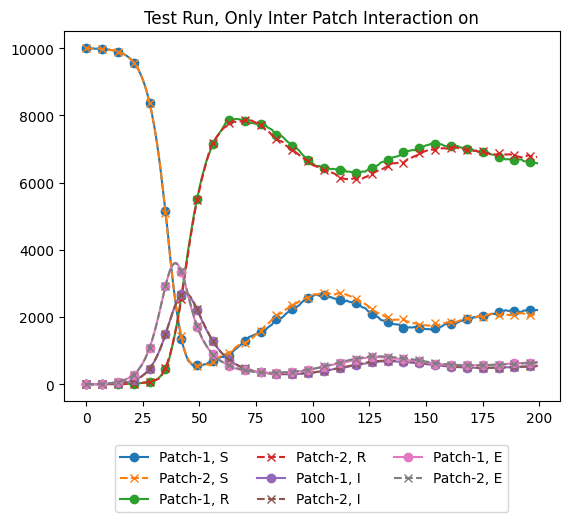

In [49]:
import matplotlib.pyplot as plt
plt.plot(patchstates[:,0, 0], marker = 'o', markevery = 7, label = 'Patch-1, S')
plt.plot(patchstates[:,1, 0], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, S')

plt.plot(patchstates[:,0, 3], marker = 'o', markevery = 7, label = 'Patch-1, R')
plt.plot(patchstates[:,1, 3], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, R')


plt.plot(patchstates[:,0, 2], marker = 'o', markevery = 7, label = 'Patch-1, I')
plt.plot(patchstates[:,1, 2], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, I')



plt.plot(patchstates[:,0, 1], marker = 'o', markevery = 7, label = 'Patch-1, E')
plt.plot(patchstates[:,1, 1], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, E')

plt.title('Test Run, Only Inter Patch Interaction on')

plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol = 3)

## Modelling Karnataka Covid 1st Wave Data

In [50]:
import pandas as pd

In [ ]:
casesfile = "IRDD_allka.csv"
casesframe = pd.read_csv(casesfile)
districts = casesframe['District'].unique()
casesframe = casesframe[casesframe['District']!='Karnataka']

In [ ]:
numpatches = len(age_stratification) * len(districts)
print(numpatches)
numagegroups = len(age_stratification)
network_matrix_patch = np.zeros((numpatches, numpatches))
for i in range(len(districts)):
    network_matrix_patch[i*numagegroups:(i+1)*numagegroups, i*numagegroups:(i+1)*numagegroups] = age_rate_contact_matrix